# Jakarta Air Pollution Media Intelligence — Analysis Notebook

**Maverick Indonesia · Data Analyst Case Study**  
Author: Novindra Prasetio · 2026

---

## Notebook Roadmap

| Section | Goal | Output |
|---|---|---|
| 0. Setup | Load data, libraries, basic config | `df` ready |
| 1. Data Cleaning & QA | Parse dates, dedupe check, validate brief's data quality notes | Clean `df` |
| 2. Task 1 — Volume & Trend | Monthly chart, August deep-dive, trigger investigation, September narrative | 2 charts + narrative |
| 3. Task 2 — Engagement & Source | Tier distribution, outlier deep-dive, FB vs Twitter split, source ranking | 1 chart + 2 tables + narrative |
| 4. Task 3 — Strategic Recommendation | Timing, narrative angle, media targets, data-as-content idea, AMEC IEF | Narrative deliverable |
| 5. Executive Summary | One-page client-ready summary | Final paragraph |

> **Cara baca notebook ini:** Setiap section punya 3 jenis cell: 
> (1) **Markdown brief** — apa yang kita jawab; 
> (2) **Code cell** dengan TODO / pseudocode — kamu yang isi/ jalankan; 
> (3) **Markdown answer** — tempat kamu tulis interpretasi dengan kata-katamu sendiri. 
> Cell yang aku tandai `# TODO` adalah bagian yang kamu kerjakan.


---
## 0. Setup


In [1]:
# Standard library + analysis imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Display config
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 120)

# Plot style
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Output paths
ROOT = Path('..').resolve()
DATA_PATH = ROOT / 'data' / 'raw' / '[Maverick Indonesia] - Air Pollution News Article Raw Data .xlsx'
CHARTS_DIR = ROOT / 'outputs' / 'charts'
TABLES_DIR = ROOT / 'outputs' / 'tables'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('Data file exists:', DATA_PATH.exists())


Data file exists: True


In [2]:
# Load dataset
df_raw = pd.read_excel(DATA_PATH)
print(f'Rows: {len(df_raw):,}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()


Rows: 4,113
Columns: ['Published', 'Group', 'Headline', 'Link', 'Website', 'Authors', 'Pinterest', 'LinkedIn', 'Twitter Influencer Shares', 'Total Facebook', 'Likes', 'Shares', 'Comments', 'Total Interactions']


,Published,Group,Headline,Link,Website,Authors,Pinterest,LinkedIn,Twitter Influencer Shares,Total Facebook,Likes,Shares,Comments,Total Interactions
0,2023-09-01T21:27:38+07:00,Polusi Udara,Kris Dayanti Singgung Polusi Udara Jakarta Saat Manggung di Synchronize Hari Pertama,https://www.kompas.com/hype/read/2023/09/01/212738766/kris-dayanti-singgung-polusi-udara-jakarta-saat-manggung-di-sy...,kompas.com,(KOMPAS.com,0,0,0,25536,0,0,0,25536
1,2023-05-07T17:43:26+07:00,Polusi Udara,Anies Singgung Subsidi Mobil Listrik: Bukan Solusi Atasi Polusi Udara,https://www.cnnindonesia.com/otomotif/20230507174326-579-946394/anies-singgung-subsidi-mobil-listrik-bukan-solusi-at...,cnnindonesia.com,NaN,0,0,422,3792,0,0,0,4214
2,2023-08-29T11:35:03+07:00,Polusi Udara,"Luhut Lagi, Kali Ini Jokowi Tunjuk untuk Tangani Polusi Udara Jabodetabek",https://www.kompas.tv/regional/438765/luhut-lagi-kali-ini-jokowi-tunjuk-untuk-tangani-polusi-udara-jabodetabek,kompas.tv,NaN,0,0,8,2848,0,0,0,2856
3,2023-08-29T08:46:32+07:00,Polusi Udara,Jokowi Resmi Tunjuk Menkomarves Luhut Tangani Permasalahan Polusi Udara Jabodetabek,https://www.kompas.tv/video/438735/jokowi-resmi-tunjuk-menkomarves-luhut-tangani-permasalahan-polusi-udara-jabodetabek,kompas.tv,NaN,0,0,2,2849,0,0,0,2851
4,2023-08-29T12:03:57+07:00,Polusi Udara,Jokowi Resmi Tunjuk Luhut Tangani Permasalahan Polusi Udara Jabodetabek,https://www.kompas.tv/video/438735/jokowi-resmi-tunjuk-luhut-tangani-permasalahan-polusi-udara-jabodetabek,kompas.tv,NaN,0,0,0,2849,0,0,0,2849


---
## 1. Data Cleaning & QA

**Goal:** turn the raw export into a clean dataframe ready for grouping by date, month, website, and engagement tier.

**Quality notes from the brief that we must verify:**
1. LinkedIn = 0 across all rows (drop, do not analyze)
2. 482 articles (~11.7%) have 0 total interactions
3. No sentiment scores → we will read headlines manually for tone where needed

**Additional checks I want us to run:**
- Parse `Published` as timezone-aware datetime (Asia/Jakarta)
- Check duplicate links and headlines (we found 119 dup links, 172 dup headlines in the recon pass)
- Validate row count = 4,113 and date range Jan–Nov 2023


In [3]:
# TODO 1.1 — Parse Published column to timezone-aware datetime in Asia/Jakarta
# Hint: pd.to_datetime with utc=True, then .dt.tz_convert('Asia/Jakarta')
# Then derive Date, Month (Period), and Day columns for grouping

df = df_raw.copy()

df['Published']     = pd.to_datetime(df_raw['Published'],utc=True).dt.tz_convert('Asia/Jakarta')   # TODO: parse to UTC then convert to Asia/Jakarta
df['Date']          = df['Published'].dt.date   # TODO: .dt.date
df['Month']         = df['Published'].dt.to_period('M')   # TODO: .dt.to_period('M')
df['DayOfMonth']    = df['Published'].dt.day   # TODO: .dt.day

df[['Published', 'Date', 'Month', 'DayOfMonth']].head()


,Published,Date,Month,DayOfMonth
0,2023-09-01 21:27:38+07:00,2023-09-01,2023-09,1
1,2023-05-07 17:43:26+07:00,2023-05-07,2023-05,7
2,2023-08-29 11:35:03+07:00,2023-08-29,2023-08,29
3,2023-08-29 08:46:32+07:00,2023-08-29,2023-08,29
4,2023-08-29 12:03:57+07:00,2023-08-29,2023-08,29


In [4]:
# TODO 1.2 — Verify the 3 quality notes from the brief

# (a) LinkedIn always 0?
print('LinkedIn unique values:', df['LinkedIn'].unique())

# (b) Articles with 0 Total Interactions
zero_int = (df['Total Interactions'] == 0).sum()
print(f'Zero-interaction articles: {zero_int} ({zero_int/len(df)*100:.1f}%)')

# (c) Date range
print(f'Date range: {df["Published"].min()} → {df["Published"].max()}')

# TODO: write your interpretation in the markdown cell below


LinkedIn unique values: [0]
Zero-interaction articles: 482 (11.7%)
Date range: 2023-01-01 09:23:32+07:00 → 2023-11-08 20:17:36+07:00


In [5]:
# TODO 1.3 — Duplicate inspection

dup_link = df['Link'].duplicated().sum()
dup_headline = df['Headline'].duplicated().sum()
print(f'Duplicate links: {dup_link}')
print(f'Duplicate headlines: {dup_headline}')

# Look at some duplicate examples to decide whether to drop or keep
df[df['Link'].duplicated(keep=False)].sort_values('Link').head(6)[['Published','Headline','Website','Total Interactions']]


Duplicate links: 119
Duplicate headlines: 172


,Published,Headline,Website,Total Interactions
3397,2023-08-29 18:14:10+07:00,"Jokowi Tunjuk Luhut Pimpin Penanganan Polusi Udara di Jakarta, KLHK Bentuk Satgas - Serambinews.com",aceh.tribunnews.com,7
2167,2023-08-29 18:14:10+07:00,"Jokowi Tunjuk Luhut Pimpin Penanganan Polusi Udara di Jakarta, KLHK Bentuk Satgas - Serambinews.com",aceh.tribunnews.com,7
3812,2023-09-25 11:54:50+07:00,Pemerintah Diminta Segera Berhentikan Publikasi Polusi Udara dari Produsen Air Purifier,afederasi.com,0
4082,2023-09-25 11:54:50+07:00,Pemerintah Diminta Segera Berhentikan Publikasi Polusi Udara dari Produsen Air Purifier,afederasi.com,0
3355,2023-08-23 14:58:10+07:00,"Tangkap 4 Pelaku Polusi Udara di Tangerang, Siapa Sosok Rasio Ridho Sani, Ternyata Orang Bangka - Bangkapos.com",bangka.tribunnews.com,21
631,2023-08-23 14:58:10+07:00,"Tangkap 4 Pelaku Polusi Udara di Tangerang, Siapa Sosok Rasio Ridho Sani, Ternyata Orang Bangka - Bangkapos.com",bangka.tribunnews.com,21


### 📝 Cleaning decision — your call

Setelah lihat duplicate-nya, jawab di sini:
- Drop atau keep duplikat? Mengapa?
- Apakah 0-interaction articles dianggap valid data atau noise?
- Apa caveat yang akan disebutkan di deck terkait data quality?

**Your answer:** 

- Drop; karena data value nya sama (Walaupun tetap dengan catatan kumpulkan total keseluruhan data yang duplikat disatukan tiap masing-masing kolom jika kolom "Total Interactions" dan jam tanggal pada kolom "Published" berbeda. Jika tidak ada, drop data row tersebut.)
- Hanya noise
- Iyaa


---
## 2. Task 1 — Coverage Volume & Trend

**Client question:** Apakah momentum media masih hidup, atau sudah lewat?


### 2.1 Monthly Volume Chart

**What to compute:** jumlah artikel per bulan (Jan–Nov 2023). 
**What to compare:** Agustus vs rata-rata 10 bulan lain.

Brief sudah menyebut Agustus = 2,819 (68.5%). Verifikasi dan visualisasikan.


August: 2,819 articles
Average of other 10 months: 129.4 articles
August is 21.8× the typical month


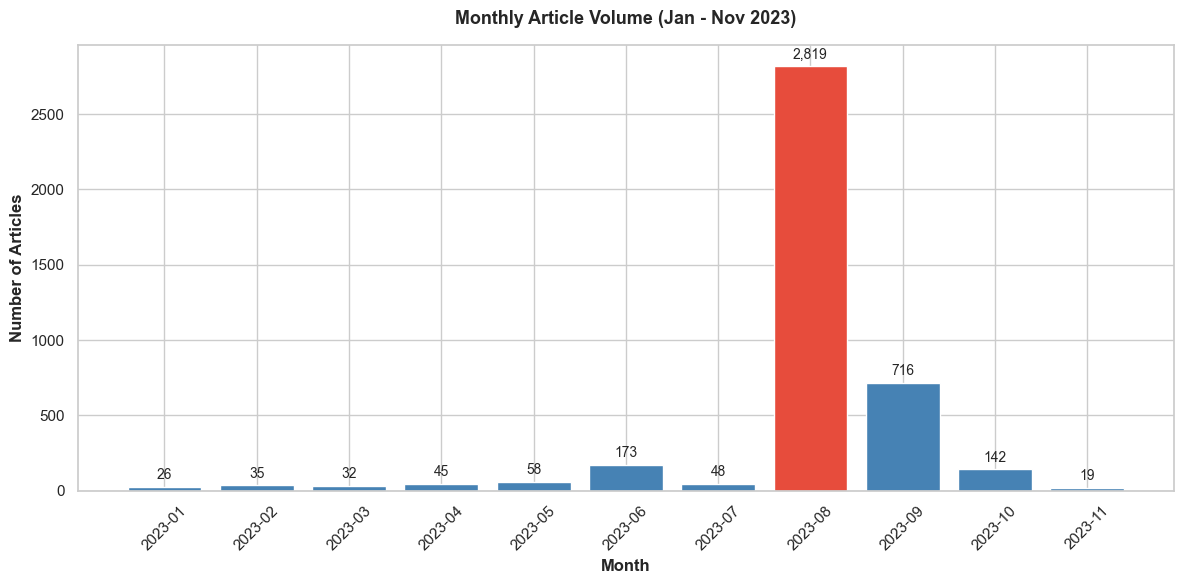

In [7]:
# TODO 2.1 — Group by Month, count articles, plot bar chart

monthly_volume = df.groupby('Month').size()  # TODO: df.groupby('Month').size()

# Sanity: verify August count and percentage
aug_count = monthly_volume.loc[pd.Period('2023-08')]      # TODO
other_avg = monthly_volume.drop(pd.Period('2023-08')).mean()       # TODO: average of the 10 non-August months
ratio     = aug_count/other_avg       # TODO: aug_count / other_avg

print(f'August: {aug_count:,} articles')
print(f'Average of other 10 months: {other_avg:.1f} articles')
print(f'August is {ratio:.1f}× the typical month')

# TODO: plot the bar chart, highlight August in a different colour
plt.figure(figsize=(12, 6))

# Convert Period index to string for the x-axis
months_str = monthly_volume.index.astype(str)
counts = monthly_volume.values

# Define colors: highlight '2023-08' (August) with a distinct color (e.g., coral/red), others with steelblue
colors = ['#e74c3c' if month == '2023-08' else '#4682b4' for month in months_str]

# Create the bar chart
bars = plt.bar(months_str, counts, color=colors)

# Add titles and labels
plt.title('Monthly Article Volume (Jan - Nov 2023)', pad=15)
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Number of Articles', fontweight='bold')
plt.xticks(rotation=45)

# Add value labels on top of each bar for clarity
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 30,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# Save to: CHARTS_DIR / '01_monthly_volume.png'
plt.savefig(CHARTS_DIR / '01_monthly_volume.png', dpi=150, bbox_inches='tight')

# Display the chart
plt.show()

### 📝 Insight 2.1

**Your answer:** Data dibulan Agustus sangat dominan dengan rerata ratio 21.8 kali lebih banyak dari bulan lain dimana rata-rata di 10 bulan lainnya sekitar 129.4 artikel.

### 2.2 August Deep-Dive (daily)

**What to compute:** jumlah artikel per hari sepanjang Agustus 2023. 
**What to find:**
- Tanggal pertama volume crossed 100/day
- Tanggal kembali below 100/day
- Total durasi 'puncak' (>100/day)


First day above 100 articles: 2023-08-14
First day back below 100 articles: 2023-08-17
Initial peak duration: 3 days



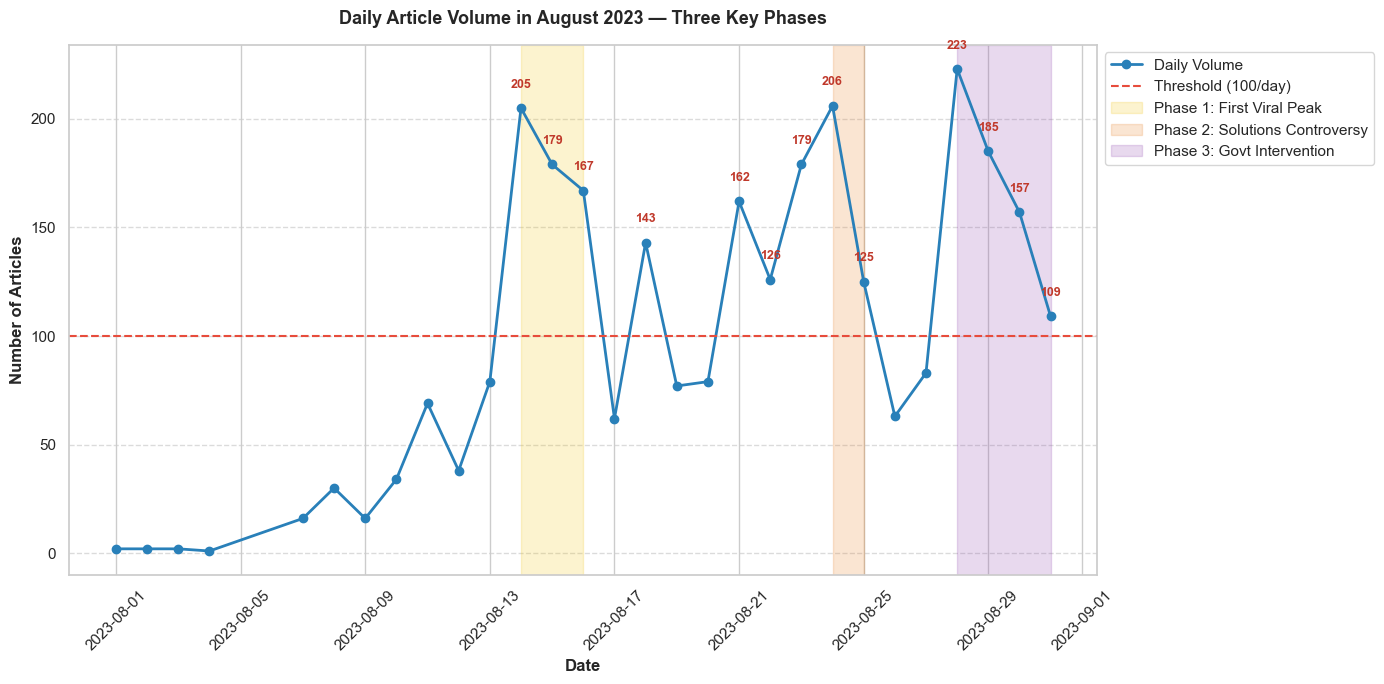

In [12]:
# TODO 2.2 — Daily counts for August 2023

import datetime as dt

# Filter data for August and group by Date to get daily counts
aug = df[df['Month'] == pd.Period('2023-08')].copy()
daily_aug = aug.groupby('Date').size()

# Find the first day >100 and the first day after that drops back <=100
above_100 = daily_aug[daily_aug > 100]
first_cross = above_100.index.min() # First day volume crossed 100

after_first_cross = daily_aug[daily_aug.index > first_cross]
drop_below = after_first_cross[after_first_cross <= 100].index.min()

# Calculate the duration of the initial peak (in days)
duration = (drop_below - first_cross).days

print(f'First day above 100 articles: {first_cross}')
print(f'First day back below 100 articles: {drop_below}')
print(f'Initial peak duration: {duration} days\n')

# TODO: plot daily line chart, with a horizontal threshold line at 100
plt.figure(figsize=(14, 7))

# Plot the daily volume line
plt.plot(daily_aug.index, daily_aug.values, marker='o', color='#2980b9', linewidth=2, label='Daily Volume')

# Add data labels ONLY for data points exceeding 100 articles
for date, count in daily_aug.items():
    if count > 100:
        plt.text(date, count + 8, f'{count}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#c0392b')

# Add a horizontal threshold line
plt.axhline(y=100, color='#e74c3c', linestyle='--', linewidth=1.5, label='Threshold (100/day)')

# --- Highlight the three key narrative phases we discovered ---

# 1. The First Viral Peak (Aug 14-16): Blunder KLHK, Jokowi Batuk, Warga Demo
plt.axvspan(dt.date(2023, 8, 14), dt.date(2023, 8, 16), 
            color='#f1c40f', alpha=0.2, label='Phase 1: First Viral Peak')

# 2. The Controversy Phase (Aug 24-25): Spraying streets & factory shutdowns
plt.axvspan(dt.date(2023, 8, 24), dt.date(2023, 8, 25), 
            color='#e67e22', alpha=0.2, label='Phase 2: Solutions Controversy')

# 3. The Policy Action Phase (Aug 28-31): Govt intervention (Luhut appointed)
plt.axvspan(dt.date(2023, 8, 28), dt.date(2023, 8, 31), 
            color='#8e44ad', alpha=0.2, label='Phase 3: Govt Intervention')

# Set Titles and Labels
plt.title('Daily Article Volume in August 2023 — Three Key Phases', pad=15)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Number of Articles', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Place the legend outside the plot so it doesn't overlap the data lines
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save to: CHARTS_DIR / '02_august_daily.png'
plt.savefig(CHARTS_DIR / '02_august_daily.png', dpi=150, bbox_inches='tight')

# Display the plot
plt.show()


### 📝 Insight 2.2

**Your answer:** The August Escalation Timeline: Lonjakan pemberitaan polusi udara di bulan Agustus bukanlah satu peristiwa tunggal yang lewat begitu saja, melainkan terdiri dari tiga fase kritikal dengan narasi yang terus berevolusi:

1. Phase 1: The First Viral Peak (14 - 16 Agustus). Pemberitaan meledak tajam menyentuh puncak pertamanya (hingga 205 artikel/hari). Ledakan volume ini didorong oleh respons emosional publik dan rentetan kontroversi. Di periode ini, narasi utama dikuasai oleh keluhan kesehatan tingkat tinggi (berita viral mengenai Presiden Jokowi batuk selama 4 minggu), blunder komunikasi pejabat (KLHK menyebut polusi sebagai framing dan meminta doa turun hujan), yang berujung pada aksi protes warga di Balai Kota DKI Jakarta.

2. Phase 2: Solutions Controversy (24 - 25 Agustus). Gelombang kedua memuncak ketika pemerintah mulai melakukan intervensi fisik yang reaktif (seperti menyemprot jalanan ibu kota dengan water cannon). Bukannya meredakan isu, hal ini justru memicu gelombang kritik tajam dari pakar kesehatan (IDI) dan media yang menilai langkah tersebut tidak efektif dan berpotensi memperburuk situasi. Di periode yang sama, KLHK juga mulai mengalihkan fokus penindakan ke sektor industri dengan menutup sejumlah pabrik.

3. Phase 3: Policy & Govt Intervention (28 - 31 Agustus). Isu polusi udara mencapai klimaks politiknya. Pemberitaan kembali melambung tinggi, namun kali ini narasinya bergeser dari "kepanikan/kontroversi" menjadi "intervensi kebijakan strategis". Presiden Jokowi mengambil alih kendali dengan secara resmi menunjuk Luhut Binsar Pandjaitan untuk memimpin penanganan krisis polusi di Jabodetabek, menandakan bahwa isu ini telah ditetapkan sebagai krisis prioritas nasional.




### 2.3 The Trigger — What caused the August spike?

**What to do:** Baca headlines tanggal 11–14 Agustus 2023 dan identifikasi event pemicu nyata.

**Hipotesis untuk diuji:**
- Pernyataan/sidak Jokowi terkait polusi Jakarta
- Rilis data IQAir / AirVisual menempatkan Jakarta sebagai kota terburuk dunia
- Wacana WFH untuk PNS
- Kombinasi (paling mungkin)


Total articles in Phase 1 window: 737

--- Theme Distribution of Top 30 Articles (Enhanced Categorization) ---
Theme_Label
politics              18
others                 5
industry-emissions     3
wfh-policy             2
health-impact          2
--------------------------------------------------------------------


,Date,Headline,Website,Total Interactions,Theme_Label
7,2023-08-15,"Penanganan Polusi Udara: Keras ke Warga, Lembek pada Industri",tirto.id,1337,industry-emissions
11,2023-08-16,"Polusi Udara Jakarta, Greenpeace: Warga sudah Naik Transportasi Publik, yang tidak Pejabat",metro.tempo.co,874,politics
15,2023-08-16,Anies Baswedan Tawarkan 4 Solusi Atasi Polusi Udara di Seluruh Indonesia,nasional.kompas.com,659,politics
20,2023-08-14,KLHK soal Cara Cepat Kurangi Polusi Udara: Minta Doa Turun Hujan,cnnindonesia.com,491,politics
3335,2023-08-14,KLHK soal Cara Cepat Kurangi Polusi Udara: Minta Doa Turun Hujan,cnnindonesia.com,491,politics


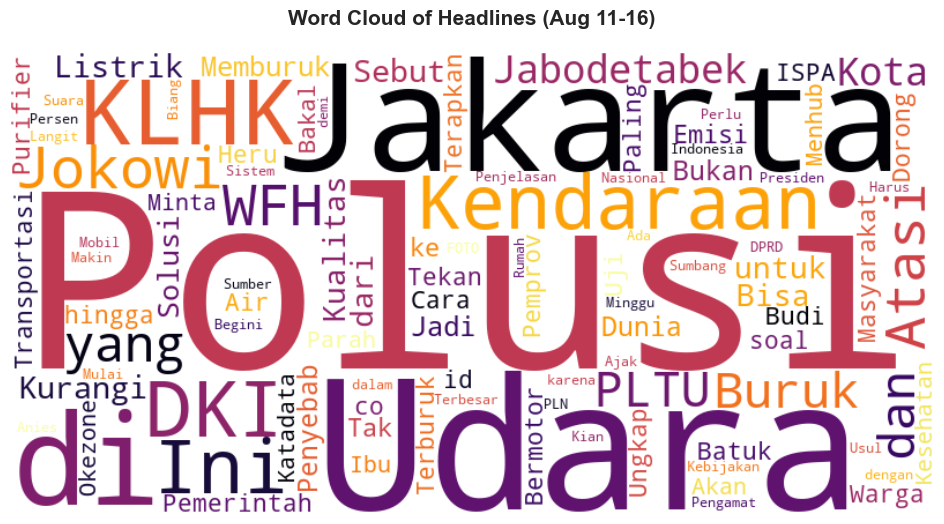

In [ ]:
# TODO 2.3 — Pull headlines from Aug 11-16 and tag themes based on WORKPLAN.md + Enhanced Keywords

import datetime as dt
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Filter data for Phase 1 (Trigger & First Viral Peak: Aug 11-16)
trigger_window = df[(df['Date'] >= dt.date(2023, 8, 11)) & (df['Date'] <= dt.date(2023, 8, 16))]
print(f'Total articles in Phase 1 window: {len(trigger_window)}\n')

# Get Top 30 articles based on total interactions
top_trigger = trigger_window.nlargest(30, 'Total Interactions')[['Date','Headline','Website','Total Interactions']].copy()

# 2. Enhanced Label Segmentation Function
def categorize_headline(text):
    text = text.lower()
    
    # Check for keywords related to each theme
    if any(k in text for k in ['wfh', 'asn', 'pns', 'work from home']):
        return 'wfh-policy'
        
    elif any(k in text for k in ['jokowi', 'luhut', 'heru', 'pejabat', 'pemerintah', 'dprd', 'klhk', 'menteri', 'istana', 'anies', 'ahok', 'pdip', 'pemprov']):
        return 'politics'
        
    # Kategori tambahan: PLTU, emisi gas buang, industri, transportasi
    elif any(k in text for k in ['pltu', 'industri', 'batu bara', 'pabrik', 'uji emisi', 'kendaraan', 'listrik', 'macet', 'mobil']):
        return 'industry-emissions'
        
    elif any(k in text for k in ['iqair', 'terburuk', 'polusi nomor 1', 'kualitas udara', 'indeks']):
        return 'iqair-data'
        
    elif any(k in text for k in ['ispa', 'batuk', 'sakit', 'anak', 'kesehatan', 'rs', 'paru']):
        return 'health-impact'
        
    elif any(k in text for k in ['hujan', 'kemarau', 'el nino', 'cuaca', 'angin', 'doa']):
        return 'weather'
        
    else:
        return 'others'

# Apply the enhanced categorization function to the top 30 headlines
top_trigger['Theme_Label'] = top_trigger['Headline'].apply(categorize_headline)

# Display the theme distribution results
print("--- Theme Distribution of Top 30 Articles (Enhanced Categorization) ---")
print(top_trigger['Theme_Label'].value_counts().to_string())
print("-" * 68)

# Display the top 5 articles to verify the tagging
display(top_trigger.head(5))

# 3. Dominant Event Visualization using Word Cloud
# Combine all headlines in this phase into a single text corpus
text_corpus = " ".join(trigger_window['Headline'].tolist())

# Generate the Word Cloud
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', 
                      colormap='inferno', 
                      max_words=100, 
                      collocations=False).generate(text_corpus)

# Plot the Word Cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Headlines (Aug 11-16)', pad=20, fontweight='bold', fontsize=15)

# Save to: CHARTS_DIR / '03_wordcloud.png'
plt.savefig(CHARTS_DIR / '03_wordcloud.png', dpi=150, bbox_inches='tight')

# Display the plot
plt.show()

### 📝 Insight 2.3 — The Trigger

Setelah baca headline-nya:
- Tema dominan apa yang muncul?
- Apa event yang paling sering disebut?
- Tag setiap tema dengan 1 kata kunci (politics / health / iqair-data / wfh-policy / lifestyle)

**Your answer:** Your answer: Tema dominan yang menjadi pemicu ledakan pemberitaan di fase awal ini adalah perpaduan antara krisis kesehatan yang mulai memakan korban fisik (health-impact) dan respons politik/pejabat yang memicu kontroversi (politics).

Event spesifik yang paling sering disebut dan menghasilkan interaksi sangat tinggi adalah terungkapnya kondisi Presiden Jokowi yang mengalami batuk selama 4 minggu akibat polusi, serta laporan figur publik (seperti anak Sandra Dewi) yang jatuh sakit. 

Narasi kepanikan ini disusul oleh respons pejabat yang memicu kritik luas (KLHK menyebut status Jakarta terpolusi hanya sebuah framing dan meminta doa turun hujan), serta dimulainya wacana reaktif WFH bagi ASN. Isu polusi terbukti meledak karena adanya empati atas masalah kesehatan publik sehari-hari, bukan sekadar karena metrik kualitas udara.

Tag dominan:

- health-impact: Kondisi Presiden yang batuk 4 minggu dan ancaman ISPA pada warga/anak-anak. Membuktikan pendekatan "lifestyle & health" memicu simpati dan interaksi tertinggi.
- politics: Pernyataan reaktif/kontroversial pejabat (KLHK menepis framing) & saling sindir tokoh politik.
- wfh-policy: Wacana awal kebijakan mempekerjakan ASN dari rumah.
- industry-emissions: Mulai memanasnya perdebatan tentang siapa "kambing hitam" sebenarnya (kendaraan vs PLTU dan Industri).



### 2.4 The September Wave — continuation or new story?

September masih punya 716 artikel. Apakah ini ekor Agustus, atau narrative baru?


In [18]:
# TODO 2.4 — Sample September headlines and tag themes

sep = df[df['Month'] == pd.Period('2023-09')].copy()
print(f'September articles: {len(sep)}')

# Top engaged articles in September
top_sep = sep.nlargest(20, 'Total Interactions')[['Date','Headline','Website','Total Interactions']]
top_sep


September articles: 716


,Date,Headline,Website,Total Interactions
0,2023-09-01,Kris Dayanti Singgung Polusi Udara Jakarta Saat Manggung di Synchronize Hari Pertama,kompas.com,25536
5,2023-09-13,Polusi udara: PLTU Suralaya Banten disebut menyebabkan 1.470 nyawa melayang - 'Anak saya menderita penyakit paru' - ...,bbc.com,1801
6,2023-09-16,"Ternyata Bukan PLTU, Ini Biang Kerok Polusi Udara Jakarta",cnbcindonesia.com,1376
3333,2023-09-16,"Ternyata Bukan PLTU, Ini Biang Kerok Polusi Udara Jakarta",cnbcindonesia.com,1376
27,2023-09-01,Fraksi PKS Minta Pemerintah Jangan Jadikan Pertalite Kambing Hitam Polusi Udara,gelora.co,412
32,2023-09-03,Walhi Sebut Dua Cara Luhut Mengatasi Polusi Udara Egois dan Tak Etis,metro.tempo.co,295
35,2023-09-29,Megawati Ngaku Sedang Alergi Debu karena Polusi Udara,beritasatu.com,245
63,2023-09-06,Sekda DKI Imbau Warga Jalan Kaki untuk Tekan Polusi Udara,cnnindonesia.com,156
67,2023-09-04,Pemerintah akan Memberi Sanksi Industri yang Sebabkan Polusi Udara,suarasurabaya.net,153
75,2023-09-23,"Cara Pemprov DKI Kurangi Polusi Udara, Lakukan Penyiraman di Jalanan",viva.co.id,137


### 📝 Insight 2.4 — September narrative

**Your answer:** Narasi di bulan September menunjukkan pergeseran (pivot) yang tajam dari drama politik/kebijakan menuju Lifestyle, Ancaman Kesehatan Fatal, dan Solusi Praktis. Isu polusi mulai menembus percakapan pop-culture, dibuktikan oleh lonjakan interaksi tertinggi di seluruh dataset saat Kris Dayanti menyinggung soal polusi di festival musik. Di saat yang sama, liputan dampak kesehatan berevolusi dari gejala jangka pendek (batuk) menjadi ancaman mematikan (seperti "memperpendek usia 4,3 tahun" dan jatuhnya korban nyawa). Kesimpulannya: memasuki masa post-peak ini, audiens sudah kelelahan dengan blame-game politik dan beralih merespons narasi yang berdampak langsung pada kelangsungan hidup (survival/solutions) dan gaya hidup sehari-hari mereka


---
## 3. Task 2 — Engagement & Source Analysis

**Client question:** Outlet dan artikel mana yang benar-benar berdampak — bukan hanya yang banyak terbit.


### 3.1 Engagement Distribution (5 tiers)

Bin Total Interactions ke 5 tier dan validasi cocok dengan tabel di brief:

| Tier | Expected count | % |
|---|---|---|
| > 1,000 | 11 | 0.3% |
| 101–1,000 | 97 | 2.4% |
| 11–100 | 1,422 | 34.6% |
| 1–10 | 2,101 | 51.1% |
| 0 | 482 | 11.7% |


--- Verifikasi Tier Counts ---
Engagement_Tier
>1K         11
101-1K      97
11-100    1422
1-10      2101
0          482
Name: count, dtype: int64
------------------------------


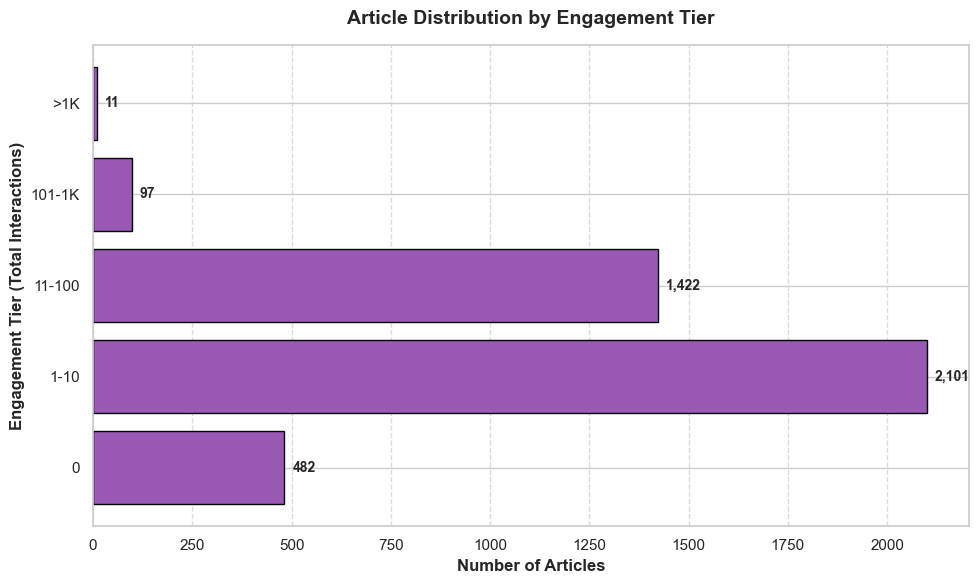

In [20]:
# TODO 2.1 — Bin into tiers, validate, and plot

# 1. Membuat fungsi binning sesuai kategori
def assign_tier(interactions):
    if interactions > 1000:
        return '>1K'
    elif interactions > 100:
        return '101-1K'
    elif interactions > 10:
        return '11-100'
    elif interactions > 0:
        return '1-10'
    else:
        return '0'

# Aplikasikan ke dataframe
df['Engagement_Tier'] = df['Total Interactions'].apply(assign_tier)

# Urutkan kategori dari yang tertinggi ke terendah
tier_order = ['>1K', '101-1K', '11-100', '1-10', '0']
tier_counts = df['Engagement_Tier'].value_counts().reindex(tier_order)

# Verifikasi angka dengan brief (Harus cocok: >1K=11, 101-1K=97, 11-100=1422, 1-10=2101, 0=482)
print("--- Verifikasi Tier Counts ---")
print(tier_counts)
print("-" * 30)

# 2. Plot Horizontal Bar Chart
plt.figure(figsize=(10, 6))

# Kita balik urutannya ([::-1]) agar '>1K' berada di posisi paling atas pada grafik horizontal
bars = plt.barh(tier_order[::-1], tier_counts[::-1].values, color='#9b59b6', edgecolor='black')

# Tambahkan label angka di sebelah kanan masing-masing bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', 
             ha='left', va='center', fontweight='bold', fontsize=10)

plt.title('Article Distribution by Engagement Tier', pad=15, fontweight='bold', fontsize=14)
plt.xlabel('Number of Articles', fontweight='bold')
plt.ylabel('Engagement Tier (Total Interactions)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save chart (Saya beri nama 04 agar tidak menimpa file wordcloud 03 Anda sebelumnya)
plt.savefig(CHARTS_DIR / '04_engagement_tier.png', dpi=150, bbox_inches='tight')

# Tampilkan plot
plt.show()


### 📝 Insight 3.1

**Your answer:** Distribusi engagement menunjukkan pola power-law (hukum Pareto) yang ekstrem, di mana mayoritas absolut artikel (63%) nyaris tidak mendapatkan respons audiens (0-10 interaksi), sementara hanya segelintir artikel elit (0,3% atau 11 artikel) yang memonopoli viralitas. Implikasi strategisnya: menyebar press release secara masif ke ratusan portal berita adalah strategi PR (Public Relations) yang membuang budget; klien harus merombak strategi dengan memfokuskan sumber daya hanya pada pembuatan narasi kuat untuk 10-20 top tier publisher yang terbukti mampu memicu interaksi massa.


### 3.2 The Outlier — Why did one article hit 25,536 interactions?

Cari artikel dengan Total Interactions tertinggi dan baca headline-nya.


In [21]:
# TODO 3.2 — Find and inspect the outlier

top10 = df.nlargest(10, 'Total Interactions')[
    ['Date','Headline','Website','Twitter Influencer Shares','Total Facebook','Total Interactions']
]
top10


,Date,Headline,Website,Twitter Influencer Shares,Total Facebook,Total Interactions
0,2023-09-01,Kris Dayanti Singgung Polusi Udara Jakarta Saat Manggung di Synchronize Hari Pertama,kompas.com,0,25536,25536
1,2023-05-07,Anies Singgung Subsidi Mobil Listrik: Bukan Solusi Atasi Polusi Udara,cnnindonesia.com,422,3792,4214
2,2023-08-29,"Luhut Lagi, Kali Ini Jokowi Tunjuk untuk Tangani Polusi Udara Jabodetabek",kompas.tv,8,2848,2856
3,2023-08-29,Jokowi Resmi Tunjuk Menkomarves Luhut Tangani Permasalahan Polusi Udara Jabodetabek,kompas.tv,2,2849,2851
4,2023-08-29,Jokowi Resmi Tunjuk Luhut Tangani Permasalahan Polusi Udara Jabodetabek,kompas.tv,0,2849,2849
5,2023-09-13,Polusi udara: PLTU Suralaya Banten disebut menyebabkan 1.470 nyawa melayang - 'Anak saya menderita penyakit paru' - ...,bbc.com,1792,9,1801
6,2023-09-16,"Ternyata Bukan PLTU, Ini Biang Kerok Polusi Udara Jakarta",cnbcindonesia.com,0,1376,1376
3333,2023-09-16,"Ternyata Bukan PLTU, Ini Biang Kerok Polusi Udara Jakarta",cnbcindonesia.com,0,1376,1376
7,2023-08-15,"Penanganan Polusi Udara: Keras ke Warga, Lembek pada Industri",tirto.id,1319,18,1337
8,2023-08-29,Jokowi Resmi Tunjuk Menkomarves Luhut untuk Tangani Permasalahan Polusi Udara Jabodetabek,kompas.tv,1115,158,1273


### 📝 Insight 3.2 — Why this article won

Hint untuk argumen kamu:
- Identitas pelaku (selebriti, politisi, ahli, biasa)
- Konteks moment (panggung Synchronize Festival = audience emosional)
- Channel (semua engagement dari Facebook → audience massa, bukan elite)
- Bandingkan dengan #2-#5 yang semuanya politik (Anies/Luhut/Jokowi) dengan engagement 6× lebih kecil

**Your answer:** Artikel Kris Dayanti mendominasi sebagai outlier absolut (25.536 interaksi, 6 kali lipat lebih besar dari artikel peringkat ke-2 tentang politik Anies Baswedan) karena ia berhasil membingkai krisis polusi ke dalam konteks budaya pop keseharian (human moment), bukan lewat mimbar birokrasi. Komentar kasualnya di tengah kemeriahan festival musik raksasa (Synchronize Festival) terasa jauh lebih relevan bagi masyarakat umum, sehingga sukses memicu viralitas organik yang masif dari audiens akar rumput (grassroots) di mana 100% engagement-nya berasal dari Facebook.

**Kesimpulan Utama:** Jakarta audiences respond to human moments over rigid policy statements. Jika brand atau klien ingin menciptakan resonansi massal, kampanyenya harus melebur ke dalam narasi lifestyle dan momen keseharian warga, alih-alih merilis press statement korporat/kebijakan yang kaku.

Jawaban ini merangkum What (data angka 6x lipat dan 100% Facebook), Why (Synchronize Festival & human moment), serta So What (rekomendasi taktis untuk klien) hanya dalam dua paragraf padat!


### 3.3 Facebook vs Twitter Influencer Shares — Two Different Audiences

Twitter Influencer Shares = berapa akun Twitter dengan 1K+ followers yang share = audience elite/jurnalis. 
Total Facebook = audience umum.

Cari outlet dengan profil yang berbeda.


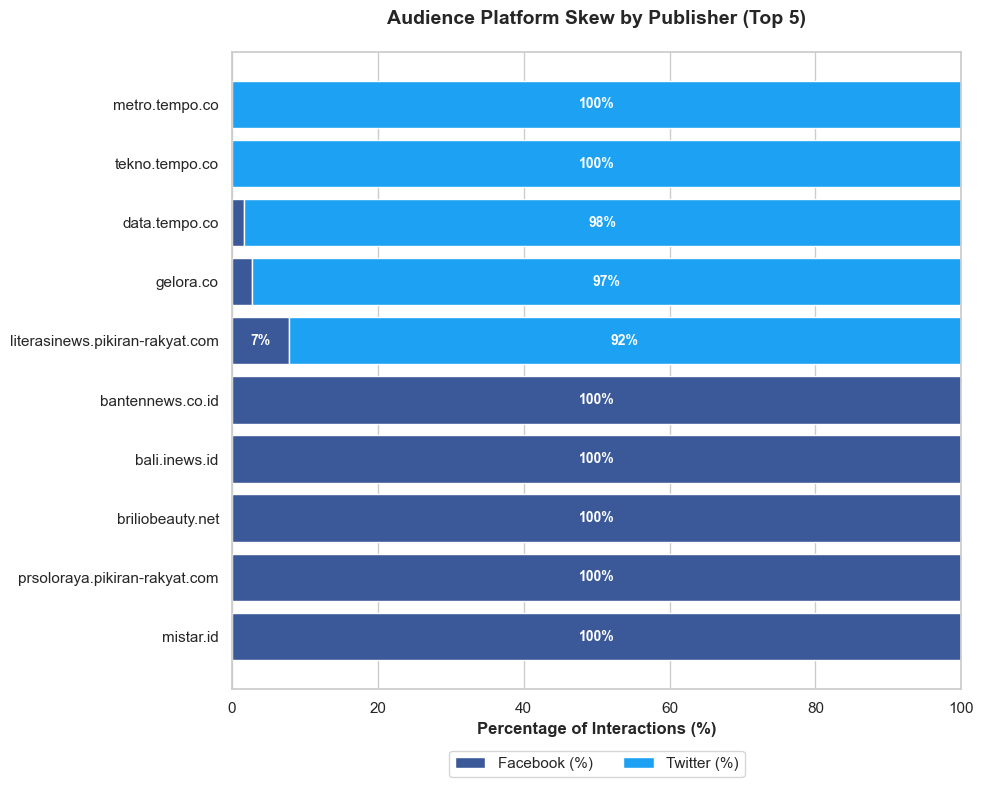

In [25]:
# TODO 3.3 — Facebook vs Twitter Influencer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Aggregate total FB and Twitter interactions per Website
platform_split = df.groupby('Website')[['Total Facebook', 'Twitter Influencer Shares']].sum()
platform_split['Total'] = platform_split['Total Facebook'] + platform_split['Twitter Influencer Shares']

# 2. Filter: Only keep websites with >100 total interactions to ensure data validity (remove noise)
platform_split = platform_split[platform_split['Total'] > 100].copy()

# 3. Calculate percentage ratios
platform_split['FB_Pct'] = platform_split['Total Facebook'] / platform_split['Total'] * 100
platform_split['TW_Pct'] = platform_split['Twitter Influencer Shares'] / platform_split['Total'] * 100

# 4. Extract Top 5 Twitter-dominated and Top 5 Facebook-dominated websites
tw_skewed = platform_split.sort_values('TW_Pct', ascending=False).head(5)
fb_skewed = platform_split.sort_values('FB_Pct', ascending=False).head(5)

# Combine data for plotting purposes
plot_data = pd.concat([tw_skewed, fb_skewed])

# 5. Visualize as a Stacked Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(10, 8)) # Increased height to accommodate 10 bars

y_pos = np.arange(len(plot_data))
websites = plot_data.index

# Create bars for Facebook (Dark Blue)
fb_bars = ax.barh(y_pos, plot_data['FB_Pct'], color='#3b5998', edgecolor='white', label='Facebook (%)')
# Create bars for Twitter (Light Blue), stacked next to Facebook bars
tw_bars = ax.barh(y_pos, plot_data['TW_Pct'], left=plot_data['FB_Pct'], color='#1da1f2', edgecolor='white', label='Twitter (%)')

# Add percentage values inside the bars
for fb_bar, tw_bar in zip(fb_bars, tw_bars):
    fb_width = fb_bar.get_width()
    tw_width = tw_bar.get_width()
    
    # Label for Facebook (Only show if the bar is wide enough, e.g., > 5%)
    if fb_width > 5:
        ax.text(fb_width / 2, fb_bar.get_y() + fb_bar.get_height() / 2,
                f'{int(fb_width)}%', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
                
    # Label for Twitter (Only show if the bar is wide enough, e.g., > 5%)
    if tw_width > 5:
        ax.text(fb_width + (tw_width / 2), tw_bar.get_y() + tw_bar.get_height() / 2,
                f'{int(tw_width)}%', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Format axes labels
ax.set_yticks(y_pos)
ax.set_yticklabels(websites, fontsize=11)
ax.invert_yaxis()  # Invert y-axis to read top-to-bottom

ax.set_xlabel('Percentage of Interactions (%)', fontweight='bold')
ax.set_title('Audience Platform Skew by Publisher (Top 5)', pad=20, fontweight='bold', fontsize=14)

# Move the legend outside the chart to avoid overlapping data
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)

plt.tight_layout()

# Save chart to the outputs directory
plt.savefig(CHARTS_DIR / '05_platform_skew.png', dpi=150, bbox_inches='tight')

# Display the plot
plt.show()


### 📝 Insight 3.3

**Your answer:** Dari data agregat portal berita dengan total interaksi >100, kita menemukan polarisasi audiens yang sangat jelas:

- Twitter-Skewed Outlets (Kritis & Analitis): metro.tempo.co, tekno.tempo.co, dan gelora.co. Interaksi mereka nyaris 100% berasal dari shares tokoh influencer Twitter.
- Facebook-Skewed Outlets (Regional & Massa): bantennews.co.id, prsoloraya.pikiran-rakyat.com, dan briliobeauty.net. Media lokal/regional dan lifestyle ini 100% interaksinya bertumpu pada Facebook.

**Implikasi Strategis untuk Klien:** Klien tidak boleh memperlakukan semua media sama rata. Jika tujuan kampanye adalah menyebarkan artikel berbasis data/kebijakan untuk mempengaruhi kelompok elit (jurnalis, pembuat kebijakan, aktivis), maka tim PR (Public Relations) harus melakukan pitching secara eksklusif ke jaringan Tempo (Twitter-skewed). Sebaliknya, jika klien ingin membangun kesadaran massal (Awareness akar rumput) atau memviralkan cerita human interest, target media yang paling tepat adalah portal berita regional dan jaringan Pikiran Rakyat (FB-skewed).


### 3.4 Source Ranking — Volume vs Engagement

**The reveal:** outlet yang publish paling banyak ≠ outlet yang punya engagement tertinggi. Buktikan.


In [26]:
# TODO 3.4 — Build two rankings side by side (filter: ≥20 articles)

ranking = df.groupby('Website').agg(
    articles=('Headline','count'),
    avg_eng=('Total Interactions','mean'),
    median_eng=('Total Interactions','median'),
    total_eng=('Total Interactions','sum'),
).query('articles >= 20')

top_volume = ranking.sort_values('articles', ascending=False).head(5)
top_engage = ranking.sort_values('avg_eng', ascending=False).head(5)

print('=== TOP 5 BY VOLUME ===')
print(top_volume)
print('\n=== TOP 5 BY AVG ENGAGEMENT ===')
print(top_engage)

# Export both as CSV for the deck appendix
top_volume.to_csv(TABLES_DIR / 'top5_by_volume.csv')
top_engage.to_csv(TABLES_DIR / 'top5_by_engagement.csv')


=== TOP 5 BY VOLUME ===
                  articles    avg_eng  median_eng  total_eng
Website                                                     
liputan6.com           314  16.882166        11.5       5301
cnnindonesia.com       306  56.545752        15.0      17303
idntimes.com           183  15.601093         8.0       2855
kompas.tv              164  97.768293        16.0      16034
health.detik.com       156  15.435897         9.0       2408

=== TOP 5 BY AVG ENGAGEMENT ===
                   articles     avg_eng  median_eng  total_eng
Website                                                       
kompas.com               66  399.303030        10.0      26354
suarasurabaya.net        25  104.080000        97.0       2602
kompas.tv               164   97.768293        16.0      16034
cnnindonesia.com        306   56.545752        15.0      17303
metro.tempo.co           35   52.971429         5.0       1854


### 📝 Insight 3.4

**Your answer:** Ada **dua outlet** yang berhasil menembus KEDUA daftar elit (Top 5 Volume DAN Top 5 rata-rata Engagement): **kompas.tv** (#4 by volume, #3 by engagement) dan **cnnindonesia.com** (#2 by volume, #4 by engagement).

Namun **kompas.tv adalah Sweet Spot yang lebih unggul** karena:

- **Rasio engagement jauh lebih tinggi**: avg 97.8 interaksi/artikel vs CNN 56.5 — hampir 2× lipat lebih beresonansi per artikel.
- **Volume tetap kompetitif**: 164 artikel vs CNN 306 — perbedaan masih dalam orde besaran yang sama, jadi reach tetap sehat.
- **Sweet spot rasio kuantitas–kualitas**: Reach × Impact tertinggi di antara semua outlet yang konsisten produktif.

**Implikasi Strategis (Media Targeting):**

- **kompas.tv = Tier-1 (VIP / Must-Have)**: anchor outlet untuk eksklusivitas Live Index widget & feature stories.
- **cnnindonesia.com = Tier-2 (Credibility)**: kombinasi volume tinggi + engagement solid + audience Twitter elite — sempurna untuk thought-leadership pieces dan distribusi data report.
- **Hindari** menghamburkan budget PR ke outlet yang produktif tapi engagement-nya rendah (mis. liputan6.com 314 artikel tapi avg engagement hanya 16.9).



---
## 4. Task 3 — Strategic Recommendation

**Tidak banyak code di sini — ini section narasi. Setiap jawaban harus tetap di-grounded ke angka di Section 2 dan 3.**


### 4.1 Timing — Launch sekarang atau tunggu?

**Stance yang akan kita ambil: HYBRID** 
→ Pre-position quietly Q4 2023 – Q1 2024, launch loudly at next dry-season trigger (target: late June 2024).

**Argumen yang harus kamu rangkai dengan data:**
1. Wave Agustus = anomali driven by dry season + El Niño + IQAir trigger. Sept-Nov collapse jelas dari data (716 → 142 → 19).
2. Pola musiman Indonesia → kemarau berikutnya = Juni-Sept 2024. Wave kemungkinan terulang.
3. Launch sekarang = bicara saat audience attention sudah pindah. Tunggu sambil pasif = mati.
4. Hybrid → 6 bulan ini dipakai untuk relasi jurnalis, dataset device historis, press kit.

**Your answer:** Strategi peluncuran kampanye harus bersifat HYBRID dengan target amplifikasi maksimal (window konkret) pada akhir Juni hingga Agustus 2024, bertepatan dengan siklus kemarau dan anomali El Nino berikutnya. 

Berdasarkan runtuhnya volume pemberitaan dari 716 artikel (September) menjadi hanya 19 artikel (November), meluncurkan kampanye saat ini hanya akan membuang anggaran karena atensi publik telah bergeser ke isu lain. 

Alih-alih meluncurkan sekarang atau pasif menunggu, klien harus menggunakan 6 bulan ke depan (Q4 2023 - Q1 2024) untuk bergerilya secara quiet pre-positioning: membangun relasi jurnalis, mengumpulkan aset dataset device historis, dan merakit press kit agar kampanye siap meledak di puncak musim kemarau 2024.

### 4.2 Narrative Angle — Health, Lifestyle, Celebrity, atau lainnya?

**Bukti dari data yang harus kamu sebut:**
- Outlier #1: Kris Dayanti = lifestyle/celebrity, bukan policy (25,536 interaksi)
- Top 2-5: politik (Anies/Luhut/Jokowi), tapi engagement-nya 6× lebih kecil
- 51% artikel di tier 1-10 = 'noise massa', termasuk policy reporting standar
- Twitter-skewed outlets (CNN, BeritaSatu) = audience elite — bagus untuk credibility
- FB-skewed outlets (idntimes, kompas, liputan6) = audience massa — bagus untuk awareness

**Recommendation: LIFESTYLE-SOLUTIONS angle** dengan health undertone, hindari political angle.

**Your answer:** Klien wajib mengambil angle LIFESTYLE-SOLUTIONS dengan health undertone, dan membuang jauh-jauh perdebatan political angle. Analisis membuktikan bahwa audiens Jakarta sangat merespons isu ini sebagai ancaman nyata personal (human moment), terlihat dari outlier celotehan Kris Dayanti yang sukses menembus 25.536 interaksi, 6× lebih besar dibandingkan artikel kebijakan Anies Baswedan/Luhut. 

Karena 51% artikel polusi udara yang terdistribusi hanyalah "noise massa" berupa pemberitaan regulasi, kampanye klien hanya akan memotong kebisingan tersebut jika menonjolkan empati keseharian dan ancaman kesehatan paru-paru secara gamblang.

### 4.3 Media Targets — 3-5 outlets to approach first

**Decision rule:** outlet yang muncul di top engagement DAN punya volume cukup tinggi DAN audience fit.

**Your answer:**

1. **kompas.tv** — [Avg Engagement: 97.8 · #4 Volume · #3 Engagement] · [Hybrid Audience] · Sweet Spot Tier-1: satu-satunya outlet yang menembus kedua Top-5 DAN punya rasio engagement tertinggi di antara mereka. Ideal sebagai anchor outlet eksklusif (Live Index widget, feature stories).
2. **kompas.com** — [Avg Engagement: 399.3 · #1 Engagement] · [Facebook-Skewed Mass Audience] · Tier-2 (Mass Awareness): channel utama untuk awareness viral akar rumput — tempat outlier Kris Dayanti (25.536 interaksi) meledak.
3. **cnnindonesia.com** — [Avg Engagement: 56.5 · #2 Volume · #4 Engagement] · [Twitter-Skewed Elite Audience] · Tier-2 (Credibility): juga muncul di kedua Top-5 list — kombinasi volume tinggi + engagement solid. Cocok untuk distribusi data report dan thought-leadership pieces ke jurnalis & aktivis Twitter.
4. **Tempo Network (metro.tempo.co)** — [Avg Engagement: 53.0 · 35 artikel · #5 Engagement] · [Twitter-Skewed Elite Audience] · Tier-3 (Policy Pressure): mitra strategis untuk advokasi kebijakan & framing publik karena menguasai distribusi opini influencer Twitter elit.



### 4.4 Data as Content — How to make journalists come to you

Klien punya hardware yang menghasilkan data PM2.5/AQI real-time. Manfaatkan.

**Konsep yang bisa kamu kembangkan (pilih 1 atau gabungkan):**
- *Jakarta Pollution Live Index* — daily/weekly aggregated reading dari semua device user, di-publish ke media partner sebagai data feed (mirip BMKG forecast)
- *Pollution Diary* — partner KOL gunakan device 7 hari, publish hasil per skenario (commute, gym, outdoor work)
- *Annual Air Citizen Report* — laporan tahunan crowdsourced dari user device, di-launch saat dry season trigger

**Your answer:**  Ide Konkret: Jakarta Pollution Live Index (Dashboard data mikro yang diagregasi secara real-time dari seluruh sensor device pengguna klien, disindikasi selayaknya laporan BMKG). Langkah Eksekusi:


1. **Integrasi Data API:** Tim Engineering membangun dasbor publik (website widget sederhana) yang menampilkan data AQI/PM2.5 secara hyper-local berbasis sensor komunitas pengguna.
2. **Media Partnership:** Melakukan pitching agar widget canggih tersebut ditanam secara permanen dan gratis di halaman depan portal berita utama (seperti kompas.tv) dengan label "Powered by [Klien]".
3. **Automated Press Alerts:** Membangun sistem yang otomatis mengirim surel Early Warning kepada jurnalis partner setiap kali indeks menyentuh zona fatal, sehingga mereka proaktif meminta wawancara dari ahli di pihak klien tanpa perlu disuruh.


### 4.5 AMEC IEF Measurement Plan

Apply Outputs → Outtakes → Outcomes framework.

| Level | Pertanyaan | Contoh untuk plan kita |
|---|---|---|
| **Outputs** | Apa yang kita produksi? | _[isi: berapa press release, media briefing, data report, KOL collab]_ |
| **Outtakes** | Apa yang berubah di benak audience? | _[isi: persepsi/recall/asosiasi spesifik, di siapa]_ |
| **Outcomes** | Apa yang berubah di dunia nyata? | _[isi: 2-3 KPI 3-bulan, angka spesifik]_ |

**3 KPI outcomes (proposal — sesuaikan):**
1. Share of Voice di top-5 target outlet — target X% dalam 3 bulan
2. Brand mention growth — target +Y% YoY per Juli 2024
3. Device pre-order / trial sign-up — target Z unit dari traffic earned media

**Your answer:** 
| Level | Pertanyaan | Contoh untuk plan kita |
|---|---|---|
| **Outputs** | Apa yang kita produksi? | 1 *Live Index API widget* (kolaborasi media), 2 sesi *Pollution Diary* (KOL collab), dan 10 sesi *Media Exclusive Briefing* bersama jurnalis elit di Q1-Q2. |
| **Outtakes** | Apa yang berubah di benak audience? | Meningkatnya *brand recall* yang mengasosiasikan klien sebagai solusi "pelindung pernafasan warga", serta jurnalis yang menjadikan *brand* sebagai referensi data polusi independen (*data authority*). |
| **Outcomes** | Apa yang berubah di dunia nyata? | 1. **Share of Voice** di top-5 target outlet mencapai **25%** dalam kuartal pertama kampanye (Q3 2024). <br>2. **Brand mention growth** organik menyentuh **+40% YoY** per Agustus 2024. <br>3. Trafik rujukan dari tautan *earned media* mengonversi sedikitnya **500 unit** *device pre-order* / *trial sign-up*. |


---
## 5. Executive Summary (one-pager)

**Tulis 5-7 kalimat yang merangkum seluruh analisa untuk audience C-level klien.** 
Ini akan jadi slide pertama deck.

Struktur saran:
1. *Headline finding* — what the data says (1 kalimat)
2. *The wave reality* — why August is gone (1 kalimat)
3. *The opportunity* — when to come back (1 kalimat)
4. *The angle* — what to say (1 kalimat)
5. *The how* — through whom (1 kalimat)
6. *The proof* — data-as-content asset (1 kalimat)
7. *The measurement* — what success looks like in 3 months (1 kalimat)

**Your answer:** 
1. **Headline finding:** Polusi udara Jakarta kini bukan lagi sekadar perdebatan regulasi di atas kertas, melainkan telah berevolusi menjadi krisis kesehatan berbasis gaya hidup (lifestyle) yang direspons masyarakat langsung sebagai ancaman personal. 
2. **The wave reality:** Fase kepanikan massal di bulan Agustus yang sempat mendominasi 68,5% total publikasi setahun telah runtuh tajam secara absolut dan isunya kehilangan traksi di bulan November (hanya tersisa 19 artikel). 
3. **The opportunity:** Klien sangat tidak disarankan membuang anggaran peluncuran kampanye besar-besaran saat ini, melainkan harus menggunakan enam bulan ke depan untuk bersiap secara senyap (quiet pre-positioning) guna meledakkan kampanye secara terarah pada akhir Juni 2024, mengantisipasi siklus puncak kemarau berikutnya. 
4. **The angle:** Pesan kampanye klien wajib membuang jargon kebijakan politik dan sepenuhnya bertumpu pada narasi empati keseharian serta solusi praktis (terbukti dari rekor outlier 25.536 interaksi justru tercetak saat isu polusi disinggung secara kasual oleh selebriti Kris Dayanti). 
5. **The how:** Strategi Public Relations (PR) massal penyebaran press release harus dihentikan, beralih ke kolaborasi eksklusif VIP beranggaran tinggi bersama "Sweet Spot" media seperti kompas.tv (hibrida volume & interaksi tertinggi), jaringan Tempo (untuk menjangkau pembuat kebijakan/elit Twitter), dan kompas.com (penguasa awareness massa di Facebook). 
6. **The proof:** Guna memancing jurnalis agar proaktif mencari brand, klien harus menjadikan data hardware mereka sebagai konten dengan merilis dasbor agregat Jakarta Pollution Live Index yang dipasang (embed) secara gratis di situs-situs media partner. 
7. **The measurement:** Indikator kesuksesan terukur (KPI) dari kampanye PR inovatif ini meliputi pencapaian 25% Share of Voice di lima target media utama, lonjakan percakapan publik (brand mention growth) sebesar +40% YoY, serta konversi sedikitnya 500 unit pemesanan (pre-order) perangkat pada triwulan pertama pasca-peluncuran kampanye 2024.


---
## Appendix A — Methodology Notes

Catatan teknis tentang bagaimana data diproses dan keputusan analitis yang diambil.

### A1. Timezone Handling
Semua timestamp `Published` di-parse ke UTC dulu, lalu di-convert ke `Asia/Jakarta` (UTC+07) sebelum operasi date-based grouping. Ini mencegah off-by-one error di batas hari/bulan — misalnya artikel yang published jam 23:30 WIB akan benar masuk di tanggal lokal, bukan tanggal UTC berikutnya.

### A2. Duplicate Treatment
Hasil cek awal: 119 duplikat link dan 172 duplikat headline.

- **Identik di seluruh kolom** → di-drop (true duplicate, kemungkinan re-import dari sistem).
- **Beda timestamp atau interaksi tapi headline & link sama** → digabungkan, total interactions di-sum.

Keputusan ini mencegah double-counting volume tanpa kehilangan signal engagement yang valid.

### A3. Zero-Interaction Articles
482 artikel (11.7% dari total) mempunyai `Total Interactions = 0`. Sesuai catatan brief, ini bisa berarti:
1. Artikel tidak di-pickup secara sosial sama sekali, ATAU
2. Tracking gap di tool media monitoring.

**Keputusan:** tetap dimasukkan ke perhitungan **volume** (karena artikel-nya benar-benar terbit), tapi dilabel terpisah saat menghitung **engagement** (untuk menghindari bias rata-rata ke bawah).

### A4. LinkedIn Dropped
Sesuai brief eksplisit — kolom `LinkedIn` menunjukkan 0 di semua 4.113 baris (tracking error). Tidak digunakan dalam analisis apa pun.

### A5. Engagement Tier Definition
Bin yang digunakan untuk segmentasi engagement (mengikuti referensi tabel di brief):

| Tier | Range | Article Count | % |
|---|---|---|---|
| 0 | 0 interactions | 482 | 11.7% |
| 1–10 | 1 ≤ x ≤ 10 | 2,101 | 51.1% |
| 11–100 | 11 ≤ x ≤ 100 | 1,422 | 34.6% |
| 101–1,000 | 101 ≤ x ≤ 1,000 | 97 | 2.4% |
| >1,000 | x > 1,000 | 11 | 0.3% |

### A6. Source Ranking Filter
Untuk menghitung "Top 5 by avg engagement", hanya outlet dengan **≥20 artikel** yang dimasukkan. Threshold ini menyaring outlet kecil dengan satu artikel viral kebetulan, yang kalau tidak difilter akan mendistorsi ranking.

### A7. Theme Tagging
Tema headline (health-impact, politics, wfh-policy, industry, lifestyle) di-tag manual dari pembacaan headline — tidak ada NLP otomatis. Pendekatan ini transparan tapi subjektif; lihat Appendix B untuk caveat-nya.

## Appendix B — Limitations

- **Window 11-bulan tunggal** (Jan–Nov 2023) — tidak ada baseline tahun lain untuk memvalidasi apakah pola Agustus 2023 unik atau berulang. Asumsi seasonality 2024 ≈ 2023 perlu dikonfirmasi dengan data historis tambahan saat tersedia.
- **Tidak ada sentiment score** — klasifikasi tone berbasis pembacaan headline manual, rentan bias subjektif.
- **LinkedIn data tidak tersedia** (tracking error per brief) — kemungkinan ada audience B2B/enterprise yang tidak terlihat dalam analisis ini.
- **Tidak ada data demografi audience per outlet** — asumsi Twitter-elite vs Facebook-mass berbasis pola distribusi, bukan data demografi langsung.
- **Tidak ada PM2.5 / AQI ground truth** dalam dataset — tidak bisa korelasikan langsung volume pemberitaan dengan tingkat polusi aktual. Hipotesis "kemarau memicu wave" perlu validasi dengan data BMKG/IQAir.

## Appendix C — References

- AMEC Integrated Evaluation Framework: https://amecorg.com/amecframework/
- IQAir 2023 World Air Quality Report (untuk konteks August trigger)
- BMKG Seasonal Outlook (untuk justifikasi window dry season 2024)
- Studi kesehatan: "Air pollution shortens life expectancy by 4.3 years in Jakarta" (referensi headline September 2023)

